# Лабораторная работа 5 — Очистка данных (числовые)

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** pandas, numpy, scikit-learn, matplotlib, seaborn

## Цель работы

Изучить методы очистки числовых данных: обнаружение и обработку пропущенных значений, выявление и удаление выбросов, проверку дубликатов и неинформативных признаков.

## Теоретическое введение

### Пропущенные значения

Пропущенные данные — одна из наиболее распространённых проблем в реальных датасетах. Различают три типа пропусков:

- **MCAR** (Missing Completely At Random) — пропуск не зависит ни от наблюдаемых, ни от ненаблюдаемых данных. Пример: случайный сбой датчика.
- **MAR** (Missing At Random) — пропуск зависит от других наблюдаемых переменных, но не от самого пропущенного значения. Пример: молодые респонденты чаще пропускают вопрос о доходе.
- **MNAR** (Missing Not At Random) — пропуск зависит от самого пропущенного значения. Пример: люди с высоким доходом отказываются его указывать.

### Методы обработки пропусков

1. **Удаление строк** (`dropna()`) — простой метод, но приводит к потере данных
2. **Удаление признаков** — если >50% значений пропущено
3. **Заполнение средним/медианой** (`fillna()`) — быстро, но занижает дисперсию
4. **SimpleImputer** (sklearn) — автоматизированное заполнение (mean, median, most_frequent)
5. **IterativeImputer** (sklearn) — многомерная импутация: каждый признак моделируется как функция остальных

### Выбросы

**Выброс** — наблюдение, значительно отличающееся от основной массы данных. Методы обнаружения:

- **IQR-метод**: выброс, если $x < Q_1 - 1.5 \cdot IQR$ или $x > Q_3 + 1.5 \cdot IQR$
- **Z-score**: выброс, если $|z| > 3$, где $z = \frac{x - \mu}{\sigma}$

Методы обработки выбросов:
- **Удаление** — простое, но теряет информацию
- **Winsorization** — замена выбросов граничными значениями (Q1 - 1.5*IQR или Q3 + 1.5*IQR)
- **Логарифмирование** — сжатие шкалы для правосторонних выбросов

### Дубликаты и неинформативные признаки

**Дубликаты** — полностью идентичные строки, которые могут искажать статистику и обучение модели.

**Неинформативные признаки** — столбцы, где >95% значений одинаковы, не несут полезной информации для классификации.

## Загрузка и первичный осмотр данных

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Библиотеки загружены')

Библиотеки загружены


In [88]:
df_original = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
print(f'Размер датасета: {df_original.shape}')
df_original.head()

Размер датасета: (1000, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [89]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

In [90]:
numeric_cols = df_original.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('length')  # длина одинакова для всех
print(f'Числовых признаков: {len(numeric_cols)}')

Числовых признаков: 57


---
## 1. Анализ пропущенных значений

Проверим наличие пропусков в исходном датасете.

In [91]:
missing = df_original.isnull().sum()
missing_pct = (missing / len(df_original) * 100).round(2)

missing_info = pd.DataFrame({
    'Пропусков': missing,
    'Процент (%)': missing_pct
})

print(f'Столбцов с пропусками: {(missing > 0).sum()} из {len(missing)}')
missing_info[missing_info['Пропусков'] > 0]

Столбцов с пропусками: 0 из 60


,Пропусков,Процент (%)


Датасет GTZAN не содержит пропущенных значений. Для демонстрации методов обработки пропусков **искусственно внесём** пропуски в 10% случайных ячеек нескольких признаков.

In [92]:
np.random.seed(42)
df = df_original.copy()

# Вносим пропуски в 5 признаков (10% значений каждого)
cols_to_corrupt = ['spectral_centroid_mean', 'mfcc1_mean', 'rms_mean',
                   'tempo', 'harmony_mean']
n_missing = int(0.10 * len(df))

for col in cols_to_corrupt:
    idx = np.random.choice(df.index, size=n_missing, replace=False)
    df.loc[idx, col] = np.nan

print('Пропуски после внесения (всего по столбцу):')
print(df[cols_to_corrupt].isnull().sum())

print('\nПропуски по жанрам:')
missing_by_genre = df.groupby('label')[cols_to_corrupt].apply(lambda g: g.isnull().sum())
print(missing_by_genre)


Пропуски после внесения (всего по столбцу):
spectral_centroid_mean    100
mfcc1_mean                100
rms_mean                  100
tempo                     100
harmony_mean              100
dtype: int64

Пропуски по жанрам:
           spectral_centroid_mean  mfcc1_mean  rms_mean  tempo  harmony_mean
label                                                                       
blues                          13          15         9     15            10
classical                       6           5        13      7             8
country                        13          11         8     10            10
disco                          10          11         9     11            11
hiphop                          6          12        10      6            12
jazz                           13           8         8     11            11
metal                          13          12        11     10             8
pop                             8           8         6     10            11
re

### Визуализация пропущенных значений

Тепловая карта пропусков позволяет увидеть паттерн — пропуски разбросаны случайно (MCAR) или группируются.

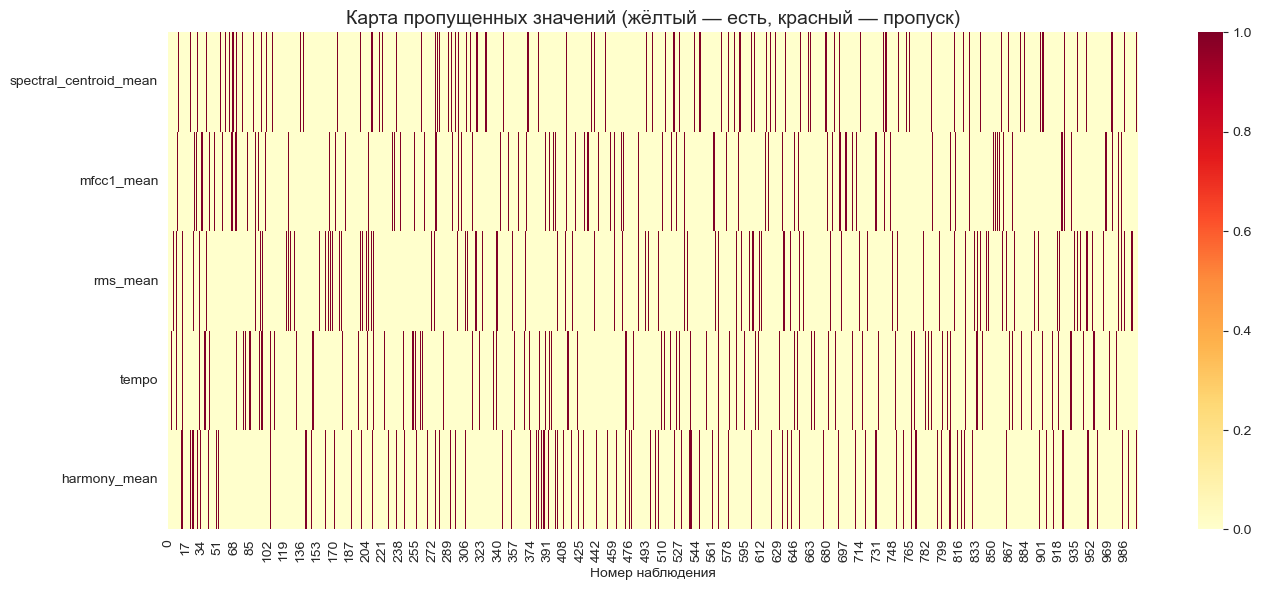

In [93]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    df[cols_to_corrupt].isnull().T,
    cbar=True, cmap='YlOrRd',
    yticklabels=True, ax=ax
)
ax.set_title('Карта пропущенных значений (жёлтый — есть, красный — пропуск)', fontsize=14)
ax.set_xlabel('Номер наблюдения')
plt.tight_layout()
plt.show()

**Интерпретация:** Пропуски распределены равномерно (что ожидаемо — мы вносили их случайно, моделируя сценарий MCAR). В реальных задачах паттерн может указывать на систематические проблемы сбора данных.

---
## 2. Заполнение пропущенных значений

### 2.1. SimpleImputer — заполнение средним и медианой

SimpleImputer из scikit-learn заполняет пропуски выбранной стратегией: средним (mean), медианой (median) или наиболее частым значением (most_frequent).

In [94]:
# Заполнение средним
imputer_mean = SimpleImputer(strategy='mean')
df_mean = df.copy()
df_mean[cols_to_corrupt] = imputer_mean.fit_transform(df[cols_to_corrupt])

# Заполнение медианой
imputer_median = SimpleImputer(strategy='median')
df_median = df.copy()
df_median[cols_to_corrupt] = imputer_median.fit_transform(df[cols_to_corrupt])

print('Пропуски после SimpleImputer (mean):', df_mean[cols_to_corrupt].isnull().sum().sum())
print('Пропуски после SimpleImputer (median):', df_median[cols_to_corrupt].isnull().sum().sum())

Пропуски после SimpleImputer (mean): 0
Пропуски после SimpleImputer (median): 0


In [96]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()

# IterativeImputer + KNN
imp_knn = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=5),
    max_iter=10, random_state=42
)
df_iter_knn = df.copy()
df_iter_knn[all_numeric] = imp_knn.fit_transform(df[all_numeric])

# IterativeImputer + случайный лес (missForest)
imp_rf = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    max_iter=10, random_state=42
)
df_iter_rf = df.copy()
df_iter_rf[all_numeric] = imp_rf.fit_transform(df[all_numeric])


### 2.2. IterativeImputer — многомерная импутация

IterativeImputer моделирует каждый признак с пропусками как функцию остальных признаков, используя регрессию. Это более точный метод, учитывающий взаимосвязи между признаками.

In [95]:
imputer_iter = IterativeImputer(max_iter=10, random_state=42)
df_iter = df.copy()

# IterativeImputer работает со всеми числовыми признаками для учёта зависимостей
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
df_iter[all_numeric] = imputer_iter.fit_transform(df[all_numeric])

print('Пропуски после IterativeImputer:', df_iter[cols_to_corrupt].isnull().sum().sum())

Пропуски после IterativeImputer: 0


### 2.3. Сравнение стратегий заполнения

Сравним, насколько заполненные значения близки к оригиналу. Для этого посмотрим на среднюю абсолютную ошибку (MAE) между оригинальными значениями и импутированными — только для тех ячеек, где мы искусственно убрали данные.

In [97]:
results = []

for col in cols_to_corrupt:
    mask = df[col].isnull()
    original_vals = df_original.loc[mask, col]

    mae_mean     = np.abs(original_vals - df_mean.loc[mask, col]).mean()
    mae_median   = np.abs(original_vals - df_median.loc[mask, col]).mean()
    mae_iter     = np.abs(original_vals - df_iter.loc[mask, col]).mean()
    mae_iter_knn = np.abs(original_vals - df_iter_knn.loc[mask, col]).mean()
    mae_iter_rf  = np.abs(original_vals - df_iter_rf.loc[mask, col]).mean()

    results.append({
        'Признак': col,
        'mean':          round(mae_mean, 4),
        'median':        round(mae_median, 4),
        'iter default':  round(mae_iter, 4),
        'iter KNN':      round(mae_iter_knn, 4),
        'iter forest':   round(mae_iter_rf, 4),
    })

comparison_df = pd.DataFrame(results)
print('MAE импутации по разным стратегиям (чем меньше — тем лучше):')
comparison_df

MAE импутации по разным стратегиям (чем меньше — тем лучше):


,Признак,mean,median,iter default,iter KNN,iter forest
0,spectral_centroid_mean,547.4189,547.6727,63.5341,395.1192,49.7817
1,mfcc1_mean,72.9466,67.7268,31.2384,64.2424,14.7092
2,rms_mean,0.0575,0.0567,0.0078,0.0516,0.0056
3,tempo,22.0891,21.4771,21.6076,25.1712,20.9497
4,harmony_mean,0.0007,0.0005,0.0006,0.0008,0.0002


In [98]:
# Нормализованная MAE: ошибка в единицах std признака
stds = df_original[cols_to_corrupt].std()
strategies = ['mean', 'median', 'iter default', 'iter KNN', 'iter forest']

normalized = comparison_df.set_index('Признак')[strategies].div(stds, axis=0)
normalized.loc['СРЕДНЕЕ'] = normalized.mean()
print('MAE / std(признак) — во сколько std составляет ошибка:')
normalized.round(3)


MAE / std(признак) — во сколько std составляет ошибка:


,mean,median,iter default,iter KNN,iter forest
Признак,,,,,
spectral_centroid_mean,0.765,0.765,0.089,0.552,0.070
mfcc1_mean,0.728,0.676,0.312,0.641,0.147
rms_mean,0.875,0.863,0.119,0.786,0.085
tempo,0.782,0.760,0.764,0.891,0.741
harmony_mean,0.416,0.297,0.356,0.475,0.119
СРЕДНЕЕ,0.713,0.672,0.328,0.669,0.232


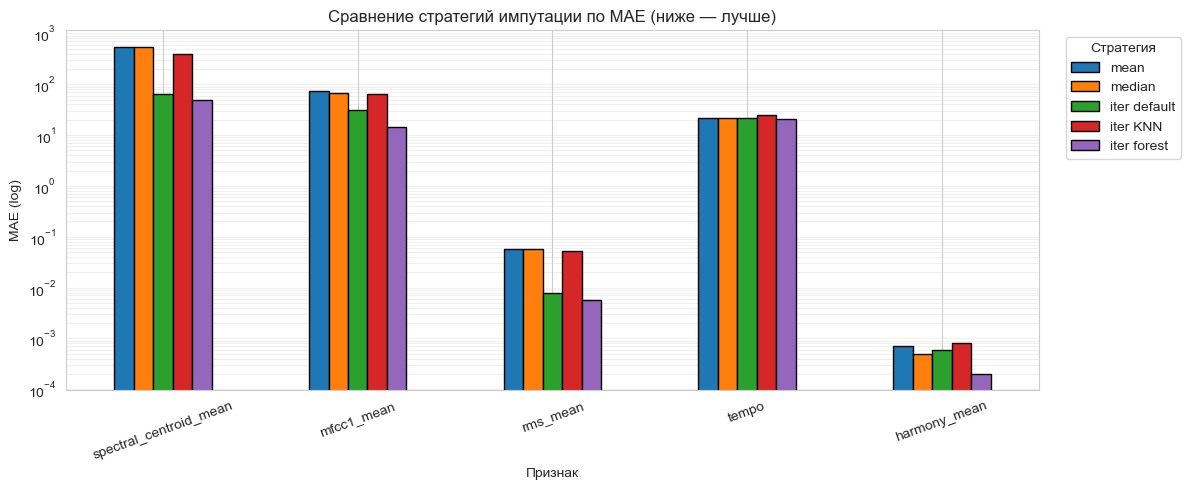

In [99]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
comparison_df.set_index('Признак')[strategies].plot(
    kind='bar', ax=ax, edgecolor='black'
)
ax.set_ylabel('MAE (log)')
ax.set_yscale('log')
ax.set_title('Сравнение стратегий импутации по MAE (ниже — лучше)')
ax.grid(True, axis='y', alpha=0.3, which='both')
ax.legend(title='Стратегия', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


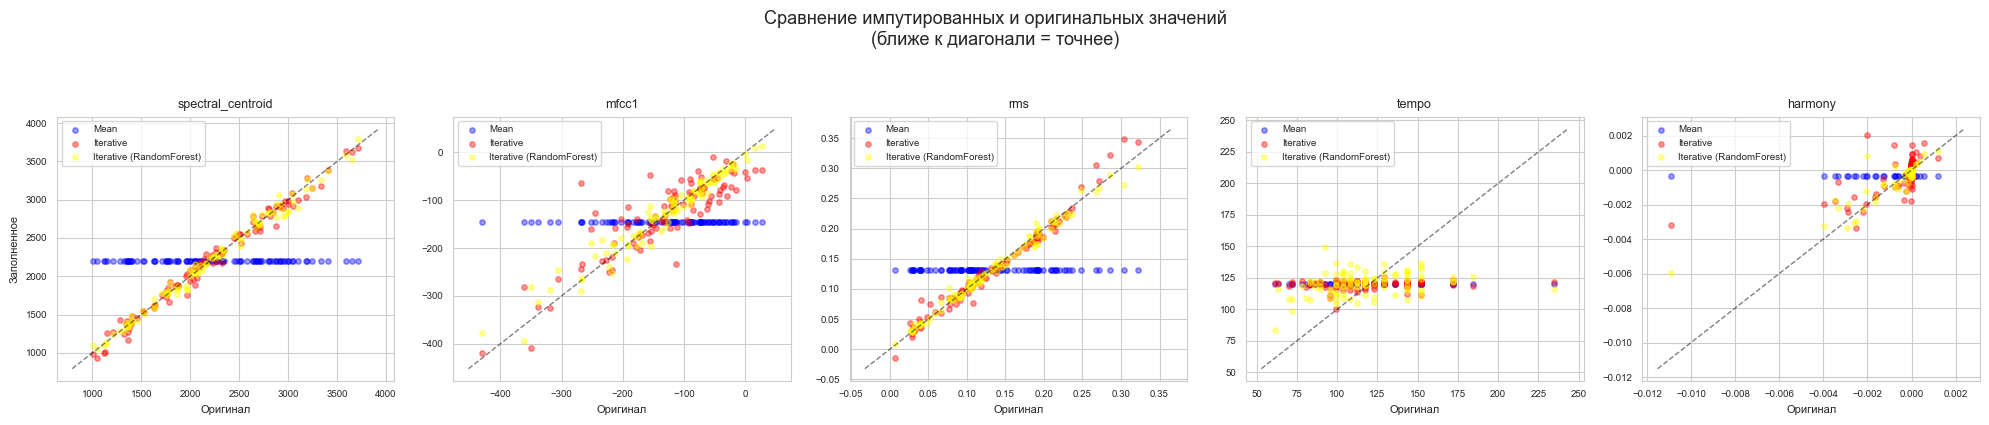

In [100]:
fig, axes = plt.subplots(1, len(cols_to_corrupt), figsize=(20, 4))

for i, col in enumerate(cols_to_corrupt):
    mask = df[col].isnull()
    ax = axes[i]

    ax.scatter(df_original.loc[mask, col], df_mean.loc[mask, col],
              alpha=0.4, s=15, label='Mean', color='blue')
    ax.scatter(df_original.loc[mask, col], df_iter.loc[mask, col],
              alpha=0.4, s=15, label='Iterative', color='red')
    ax.scatter(df_original.loc[mask, col], df_iter_rf.loc[mask, col],
            alpha=0.4, s=15, label='Iterative (RandomForest)', color='yellow')

    # Идеальная линия y=x
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)

    ax.set_title(col.replace('_mean', ''), fontsize=9)
    ax.set_xlabel('Оригинал', fontsize=8)
    if i == 0:
        ax.set_ylabel('Заполненное', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle('Сравнение импутированных и оригинальных значений\n'
             '(ближе к диагонали = точнее)', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

**Интерпретация:** IterativeImputer в целом точнее, чем SimpleImputer, поскольку учитывает взаимосвязи между признаками. Заполнение средним даёт горизонтальную линию на графике (все пропуски заполняются одним значением), тогда как IterativeImputer восстанавливает индивидуальные значения, приближаясь к диагонали.

Далее будем работать с данными, заполненными IterativeImputer.

In [101]:
# Используем результат IterativeImputer для дальнейшей работы
df_clean = df_iter.copy()
print(f'Пропуски в рабочем датасете: {df_clean.isnull().sum().sum()}')

Пропуски в рабочем датасете: 0


---
## 3. Проверка дубликатов и неинформативных признаков

### 3.1. Дубликаты

Дубликаты — полностью идентичные строки, которые могут возникать при ошибках сбора данных и искажать обучение модели.

In [102]:
# Проверка полных дубликатов
n_duplicates = df_clean.duplicated().sum()
print(f'Полных дубликатов: {n_duplicates}')

# Проверка дубликатов по числовым признакам (без filename)
n_dup_numeric = df_clean.duplicated(subset=numeric_cols).sum()
print(f'Дубликатов по числовым признакам: {n_dup_numeric}')

if n_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Размер после удаления дубликатов: {df_clean.shape}')
else:
    print('Дубликатов нет, удаление не требуется')

Полных дубликатов: 0
Дубликатов по числовым признакам: 6
Дубликатов нет, удаление не требуется


### 3.2. Неинформативные признаки

Признаки, где >95% значений одинаковы, не несут полезной информации для модели.

In [113]:
threshold = 0.95
low_info = []

for col in numeric_cols:
    top_pct = df_clean[col].value_counts(normalize=True).iloc[0]
    if top_pct >= threshold:
        low_info.append((col, round(top_pct * 100, 1)))

if low_info:
    print(f'Неинформативные признаки (>{threshold*100}% одинаковых):')
    for col, pct in low_info:
        print(f'  {col}: {pct}%')
else:
    print(f'Неинформативных признаков (>{threshold*100}% одинаковых) не найдено')

# Проверим length — он одинаков для всех
print(f'\nlength — уникальных значений: {df_clean["length"].nunique()}')
print(f'(Признак length исключён из анализа ранее как неинформативный)')

Неинформативных признаков (>95.0% одинаковых) не найдено

length — уникальных значений: 35
(Признак length исключён из анализа ранее как неинформативный)


---
## 4. Выявление выбросов

### 4.1. IQR-метод

Метод межквартильного размаха (IQR) определяет выбросы как значения, лежащие за пределами $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$. Подсчитаем количество выбросов в каждом признаке.

In [104]:
def count_outliers_iqr(data, col):
    """Подсчёт выбросов по IQR-методу."""
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    return outliers, lower, upper


outlier_stats = []
for col in numeric_cols:
    n_out, lower, upper = count_outliers_iqr(df_clean, col)
    if n_out > 0:
        outlier_stats.append({
            'Признак': col,
            'Выбросов': n_out,
            'Процент (%)': round(n_out / len(df_clean) * 100, 1),
            'Нижняя граница': round(lower, 4),
            'Верхняя граница': round(upper, 4)
        })

outlier_df = pd.DataFrame(outlier_stats).sort_values('Выбросов', ascending=False)
print(f'Признаков с выбросами: {len(outlier_df)} из {len(numeric_cols)}')
outlier_df.head(15)

Признаков с выбросами: 53 из 57


,Признак,Выбросов,Процент (%),Нижняя граница,Верхняя граница
11,harmony_mean,256,25.6,-0.0004,2.000000e-04
13,perceptr_mean,154,15.4,-0.0013,8.000000e-04
3,rms_var,92,9.2,-0.0030,7.500000e-03
10,zero_crossing_rate_var,87,8.7,-0.0027,7.500000e-03
14,perceptr_var,61,6.1,-0.0082,1.720000e-02
48,mfcc18_var,57,5.7,-8.3681,1.256382e+02
5,spectral_centroid_var,54,5.4,-457345.5767,1.253844e+06
52,mfcc20_var,52,5.2,-22.1309,1.498791e+02
12,harmony_var,50,5.0,-0.0145,3.580000e-02
50,mfcc19_var,49,4.9,-13.6642,1.340008e+02


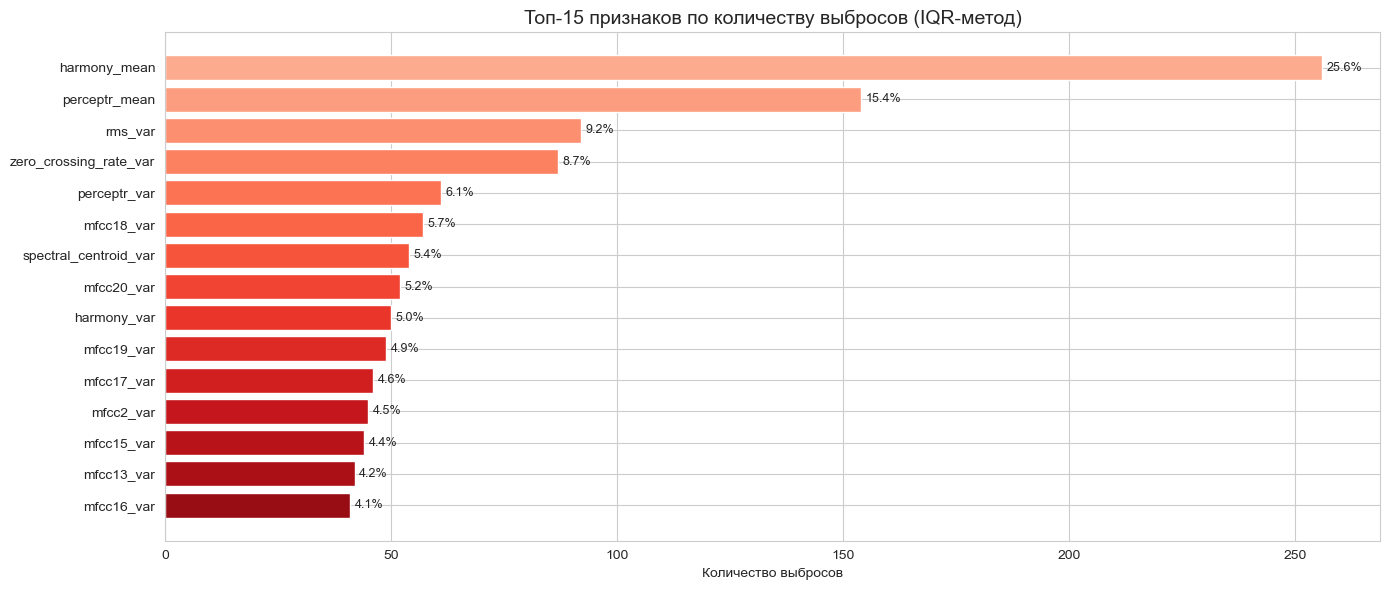

In [105]:
fig, ax = plt.subplots(figsize=(14, 6))
top_outliers = outlier_df.head(15)

bars = ax.barh(top_outliers['Признак'], top_outliers['Выбросов'],
               color=plt.cm.Reds(np.linspace(0.3, 0.9, len(top_outliers))))

for bar, pct in zip(bars, top_outliers['Процент (%)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=9)

ax.set_xlabel('Количество выбросов')
ax.set_title('Топ-15 признаков по количеству выбросов (IQR-метод)', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2. Z-score метод

Z-score показывает, на сколько стандартных отклонений значение отличается от среднего. Значения с $|z| > 3$ считаются выбросами.

In [106]:
z_threshold = 3
z_scores = np.abs(stats.zscore(df_clean[numeric_cols]))
z_outliers = (z_scores > z_threshold).sum(axis=0)

z_outlier_df = pd.DataFrame({
    'Признак': numeric_cols,
    'Выбросов (Z-score)': z_outliers
}).sort_values('Выбросов (Z-score)', ascending=False)

print(f'Метод Z-score (порог |z| > {z_threshold}):')
z_outlier_df[z_outlier_df['Выбросов (Z-score)'] > 0].head(15)

Метод Z-score (порог |z| > 3):


,Признак,Выбросов (Z-score)
3,rms_var,31
14,perceptr_mean,28
15,perceptr_var,23
42,mfcc13_var,21
13,harmony_var,20
52,mfcc18_var,20
56,mfcc20_var,20
11,zero_crossing_rate_var,19
7,spectral_bandwidth_var,19
48,mfcc16_var,18


### 4.3. Boxplot до удаления выбросов

Визуализируем распределения признаков с наибольшим количеством выбросов.

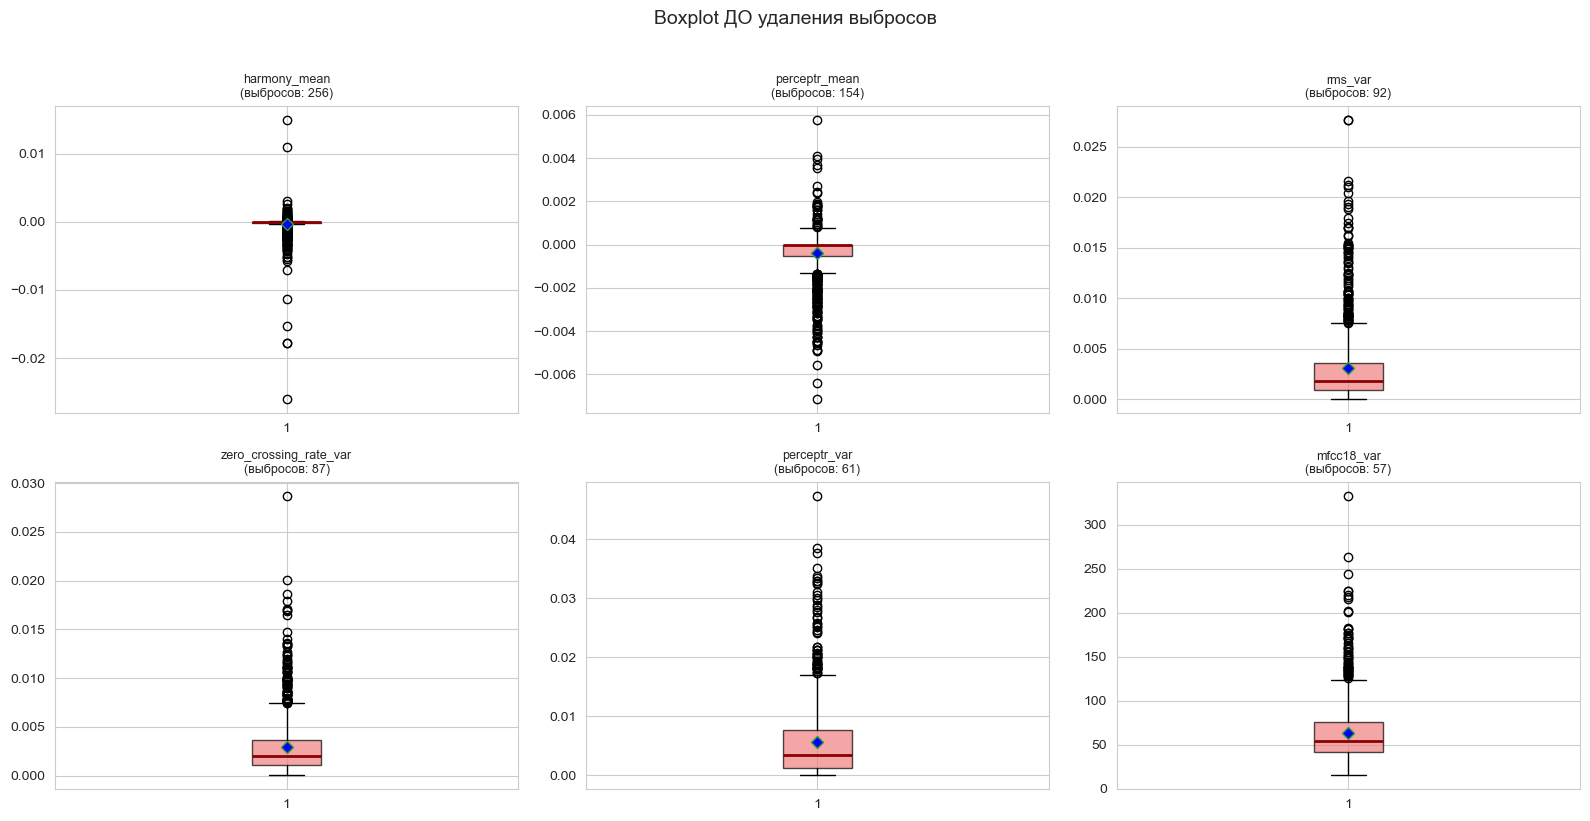

In [107]:
# Выбираем 6 признаков с наибольшим количеством выбросов
top6 = outlier_df.head(6)['Признак'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    ax = axes[i]
    bp = ax.boxplot(df_clean[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='darkred', linewidth=2),
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='blue', markersize=6))
    n_out, _, _ = count_outliers_iqr(df_clean, col)
    ax.set_title(f'{col}\n(выбросов: {n_out})', fontsize=9)

fig.suptitle('Boxplot ДО удаления выбросов', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Обработка выбросов

### 5.1. Удаление выбросов по IQR

Удалим строки, содержащие выбросы в ключевых признаках.

In [108]:
def remove_outliers_iqr(data, columns):
    """Удаление строк с выбросами по IQR для указанных столбцов."""
    mask = pd.Series(True, index=data.index)
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= (data[col] >= lower) & (data[col] <= upper)
    return data[mask].copy()


df_no_outliers = remove_outliers_iqr(df_clean, top6)
print(f'До удаления: {len(df_clean)} строк')
print(f'После удаления: {len(df_no_outliers)} строк')
print(f'Удалено: {len(df_clean) - len(df_no_outliers)} строк '
      f'({(len(df_clean) - len(df_no_outliers)) / len(df_clean) * 100:.1f}%)')

До удаления: 1000 строк
После удаления: 571 строк
Удалено: 429 строк (42.9%)


### 5.2. Winsorization — альтернатива удалению

Winsorization заменяет выбросы граничными значениями вместо удаления строк. Это сохраняет размер выборки.

In [109]:
def winsorize_iqr(data, columns):
    """Замена выбросов граничными значениями (Winsorization по IQR)."""
    result = data.copy()
    for col in columns:
        Q1 = result[col].quantile(0.25)
        Q3 = result[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        result[col] = result[col].clip(lower=lower, upper=upper)
    return result


df_winsorized = winsorize_iqr(df_clean, top6)
print(f'Размер после Winsorization: {len(df_winsorized)} строк (без потерь)')

# Проверим, что выбросов больше нет
remaining = sum(count_outliers_iqr(df_winsorized, col)[0] for col in top6)
print(f'Выбросов в top-6 признаках после Winsorization: {remaining}')

Размер после Winsorization: 1000 строк (без потерь)
Выбросов в top-6 признаках после Winsorization: 0


### 5.3. Сравнение: boxplot после обработки

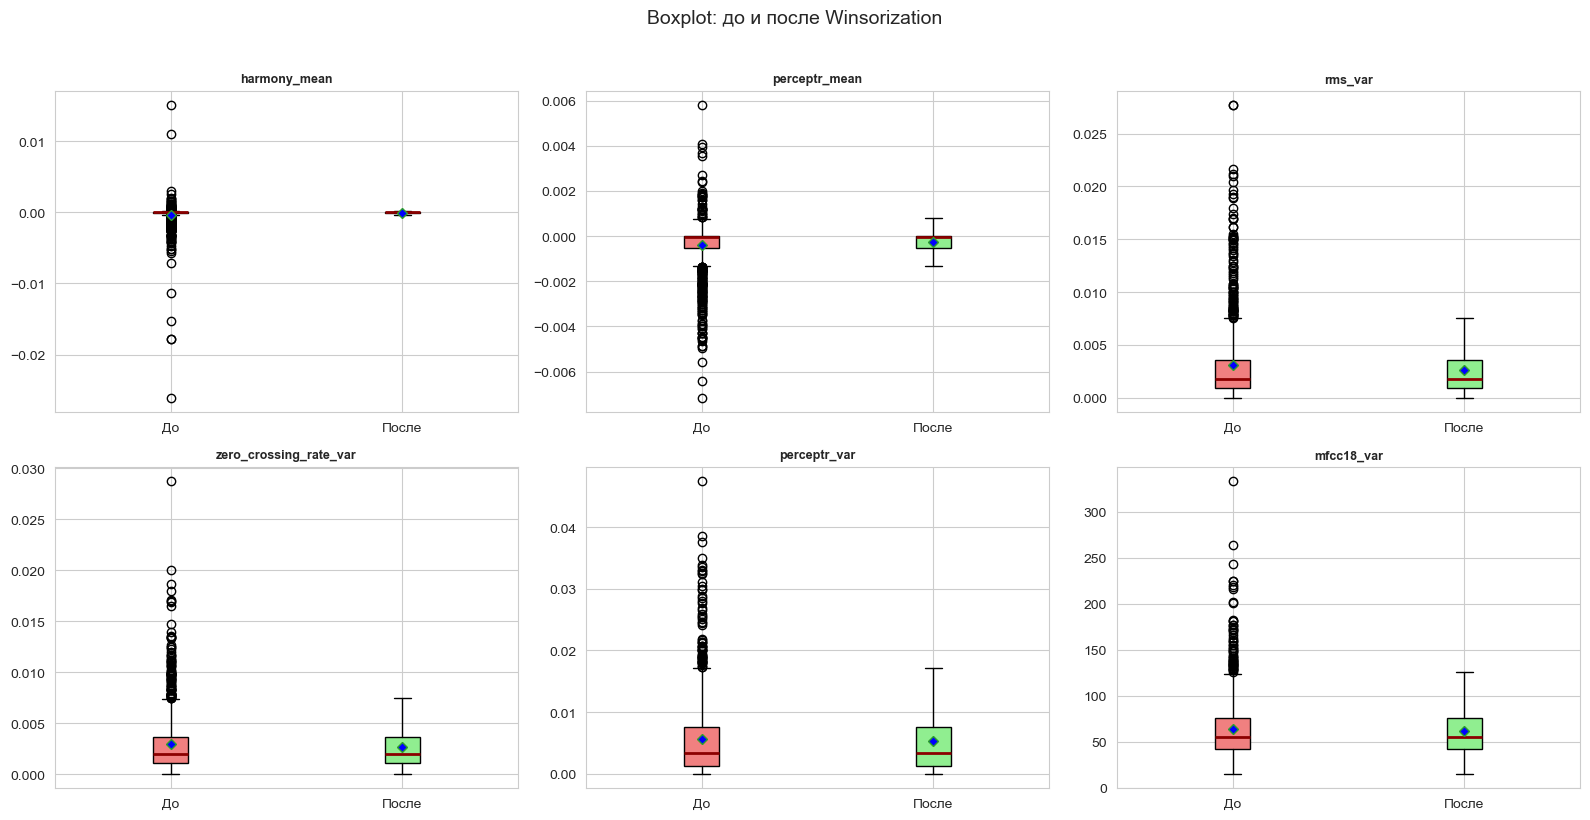

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    ax = axes[i]
    data_before = df_clean[col].values
    data_after = df_winsorized[col].values

    bp = ax.boxplot(
        [data_before, data_after],
        labels=['До', 'После'],
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='blue', markersize=5),
        medianprops=dict(color='darkred', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightgreen')
    ax.set_title(col, fontsize=9, fontweight='bold')

fig.suptitle('Boxplot: до и после Winsorization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация:** После Winsorization точки-выбросы исчезли — крайние значения заменены граничными, поэтому все наблюдения теперь укладываются в диапазон усов. Размер выборки сохранён (в отличие от удаления).

---
## 6. Итоговая статистика: до и после очистки

Сравним описательную статистику ключевых признаков до и после всех этапов очистки.

In [111]:
compare_cols = list(dict.fromkeys(top6[:4] + cols_to_corrupt))

print('=== ДО очистки (с пропусками и выбросами) ===')
print(df[compare_cols].describe().round(4))
print()
print('=== ПОСЛЕ очистки (IterativeImputer + Winsorization) ===')
print(df_winsorized[compare_cols].describe().round(4))

=== ДО очистки (с пропусками и выбросами) ===
       harmony_mean  perceptr_mean    rms_var  zero_crossing_rate_var  \
count      900.0000      1000.0000  1000.0000               1000.0000   
mean        -0.0004        -0.0004     0.0031                  0.0030   
std          0.0017         0.0011     0.0036                  0.0030   
min         -0.0261        -0.0071     0.0000                  0.0000   
25%         -0.0001        -0.0005     0.0009                  0.0011   
50%         -0.0000        -0.0000     0.0018                  0.0020   
75%          0.0000        -0.0000     0.0036                  0.0036   
max          0.0151         0.0058     0.0277                  0.0287   

       spectral_centroid_mean  mfcc1_mean  rms_mean     tempo  
count                900.0000    900.0000  900.0000  900.0000  
mean                2199.6513   -146.2357    0.1308  119.8075  
std                  722.3123    101.3179    0.0652   28.2934  
min                  570.0404   -552.120

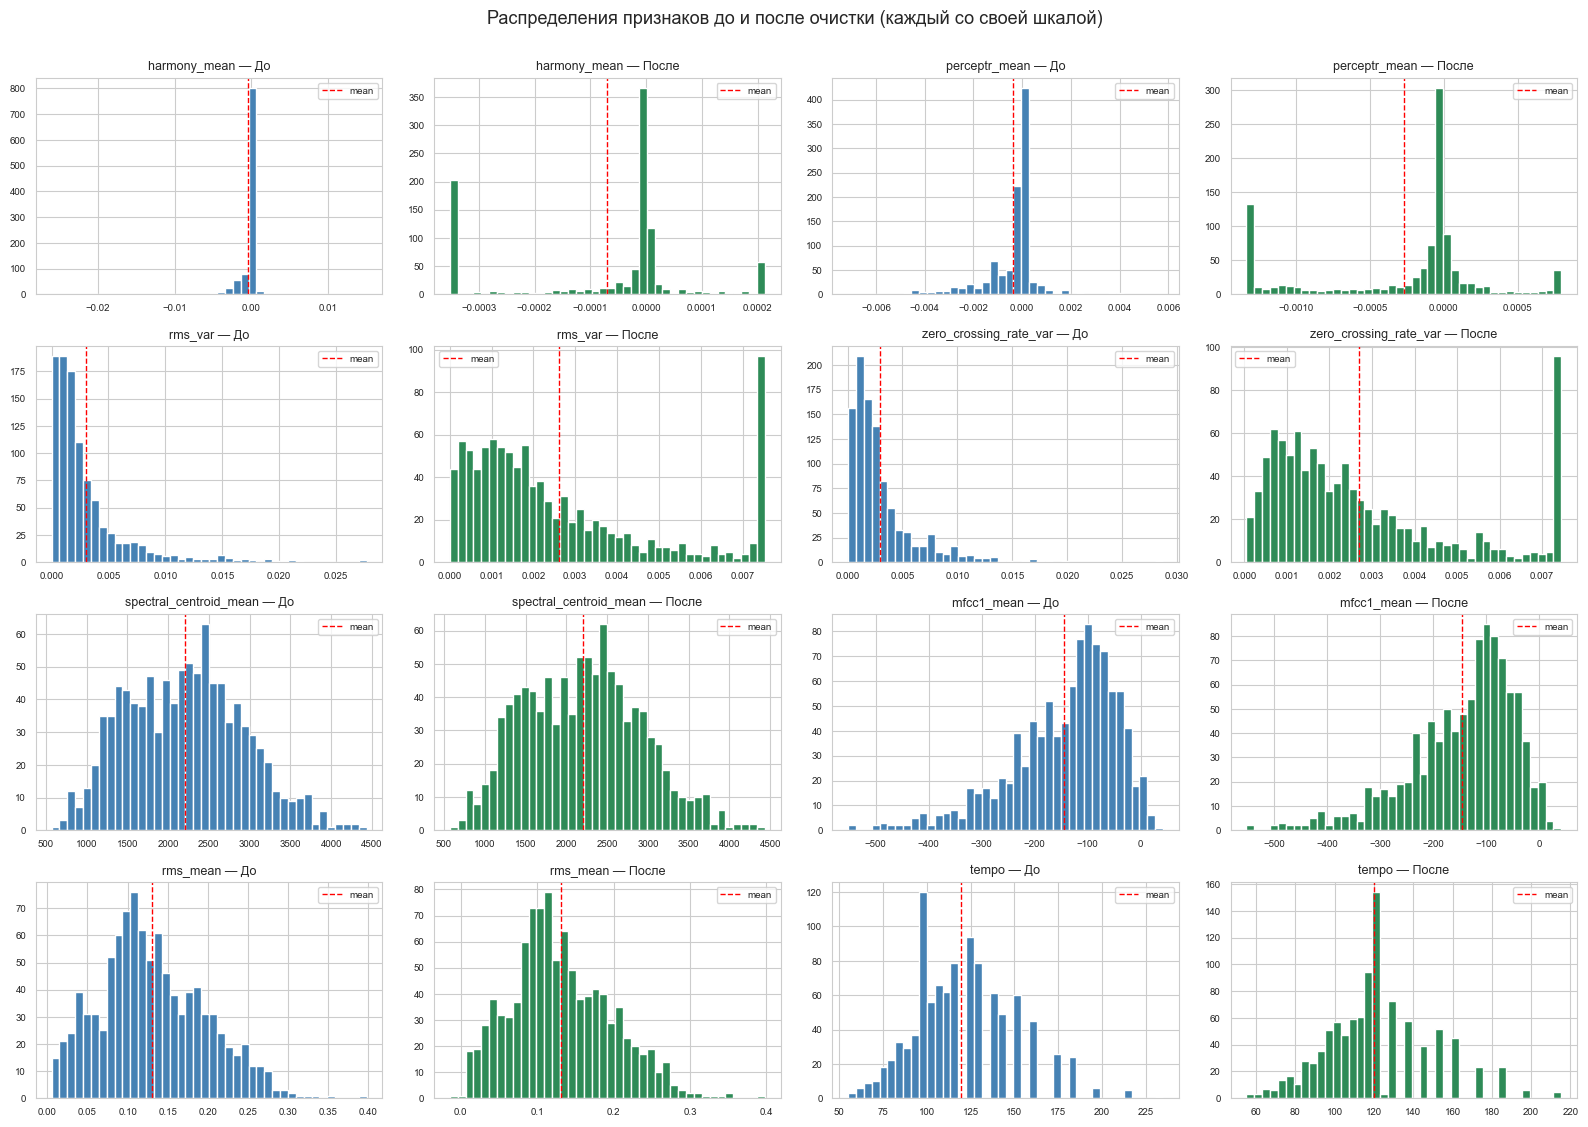

In [112]:
n = len(compare_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols * 2, figsize=(16, 2.8 * nrows))

for i, col in enumerate(compare_cols):
    row, group = i // ncols, i % ncols
    ax_l = axes[row, group * 2]
    ax_r = axes[row, group * 2 + 1]

    ax_l.hist(df_original[col], bins=40, color='steelblue', edgecolor='white')
    ax_l.axvline(df_original[col].mean(), color='red', ls='--', lw=1, label='mean')
    ax_l.set_title(f'{col} — До', fontsize=9)
    ax_l.tick_params(labelsize=7)
    ax_l.legend(fontsize=7)

    ax_r.hist(df_winsorized[col], bins=40, color='seagreen', edgecolor='white')
    ax_r.axvline(df_winsorized[col].mean(), color='red', ls='--', lw=1, label='mean')
    ax_r.set_title(f'{col} — После', fontsize=9)
    ax_r.tick_params(labelsize=7)
    ax_r.legend(fontsize=7)

# Скрываем пустые ячейки, если признаков нечётное число
for j in range(n, nrows * ncols):
    row, group = j // ncols, j % ncols
    axes[row, group * 2].axis('off')
    axes[row, group * 2 + 1].axis('off')

fig.suptitle('Распределения признаков до и после очистки (каждый со своей шкалой)',
             fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

**Интерпретация:**

- **Признаки с Winsorization** (`harmony_mean`, `perceptr_mean`, `rms_var`, `zero_crossing_rate_var`): на гистограммах «После» видны **характерные обрывы на границах** `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` — туда «стёк» весь хвост распределения. Центральная масса (основная часть данных) сохранена без искажений; обрезаны только экстремальные значения. Это осознанный компромисс: теряем редкие экстремумы ради устойчивости моделей к выбросам.

- **Признаки после IterativeImputer с хорошим качеством** (`spectral_centroid_mean`, `mfcc1_mean`, `rms_mean`): распределения «До» и «После» почти идентичны — импутация восстановила 100 пропущенных значений, не сдвинув mean/std. Это подтверждает, что `IterativeImputer` корректно использовал зависимости между признаками (MAE ≈ 0.1 std).

- **Артефакт импутации на `tempo`**: в «После» виден **резкий пик у среднего (~120 BPM)**, которого нет в «До». Это **не** winsor — tempo в `top6` не входит. Причина видна из таблицы MAE (раздел 2.3): для tempo `iter default` = 0.76 std, почти как у `mean` = 0.78 std. Регрессионный `IterativeImputer` **не смог предсказать** tempo по другим признакам (tempo слабо коррелирует с MFCC/spectral features) → скатился к mean-like заполнению → все 100 импутированных значений сгруппировались близко к среднему, породив артефактный пик.

- **Ключевой вывод:** `IterativeImputer` хорош только тогда, когда пропущенный признак **можно предсказать регрессией** из других. Для слабо-коррелированных фичей он деградирует до `SimpleImputer(mean)` со всеми её проблемами (искусственный пик, заниженная дисперсия). Это надо проверять через MAE на искусственно внесённых пропусках (раздел 2.3): если `MAE / std ≈ 1` — импутация плохая независимо от стратегии, и лучше либо искать коррелированные признаки, либо удалять строки с пропусками, либо использовать более мощный estimator (`RandomForest` дал для tempo 0.74 std — тоже не сильно лучше).

- **Признак `harmony_mean`** демонстрирует оба эффекта одновременно: и impute (count 900 → 1000), и winsor (обрывы на границах).

---
## Выводы

В ходе лабораторной работы мы изучили и применили основные методы очистки числовых данных:

### Основные результаты:

1. **Пропущенные значения:** Датасет GTZAN изначально не содержал пропусков. Для демонстрации методов мы искусственно внесли 10% пропусков в 5 признаков и сравнили три стратегии заполнения:
   - SimpleImputer (mean) — самый простой, но наименее точный
   - SimpleImputer (median) — устойчив к выбросам
   - **IterativeImputer** — наиболее точный, учитывает зависимости между признаками

2. **Дубликаты:** В датасете GTZAN дубликаты не обнаружены — каждая аудиозапись уникальна.

3. **Неинформативные признаки:** Признак `length` одинаков для всех записей (30 секунд), поэтому исключён из анализа.

4. **Выбросы:** Обнаружены во множестве признаков. Два метода обнаружения:
   - IQR-метод выявил выбросы в большинстве числовых признаков
   - Z-score метод показал схожие результаты с другим порогом чувствительности

5. **Обработка выбросов:** Сравнили два подхода:
   - Удаление строк — потеря данных
   - **Winsorization** — замена выбросов граничными значениями, сохраняет объём выборки

### Практическое значение:

Очистка данных — критический этап пайплайна ML. Некорректная обработка пропусков и выбросов может привести к смещённым моделям. Выбор метода зависит от природы данных, типа пропусков (MCAR/MAR/MNAR) и задачи. Важно помнить, что импутацию следует выполнять **после** разделения на train/test, чтобы избежать утечки данных.